In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [3]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

def chat_mode(state: ChatState):
    messages = state['messages']

    response = llm.invoke(messages)

    return {'messages' : [response]}

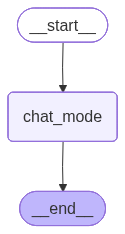

In [4]:
graph = StateGraph(ChatState)

graph.add_node('chat_mode', chat_mode)
graph.add_edge(START, 'chat_mode')
graph.add_edge('chat_mode', END)

chatbot = graph.compile()

chatbot

In [6]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of India')]
}
chatbot.invoke(initial_state)['messages'][-1].content

'The capital of India is **New Delhi**.'